# EDA Part 1

In [1]:
import os
import pandas as pd
import numpy as np
import functions as func
from passwords import *
import boto3

### Functions

In [2]:
# download from s3
def download_from_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
        aws_access_key_id=aws_access_key_id,
        aws_secret_access_key=aws_secret_access_key,
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

### Constants

In [3]:
str_project = os.getcwd().split('\\')[4].replace('_','-')
print(f'Project: {str_project}')
str_step = os.getcwd().split('\\')[-1]
print(f'Step: {str_step}')
str_dirname_output = './output'

str_id = 'uniqueid__app'
str_datecol = 'applicationdate__app'
str_variant = 'model4'

list_cols_id = [
#     str_id,
#     str_datecol,
#     'yhat_ad',
#     'yhat_pricing_pd',
#     'yhat_pricing_lgd',
#     'pricing_ecnl',
]

Project: 20231010-gen-xii
Step: 02_eda


### Output

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [5]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Import data

In [6]:
%%time

# download
str_filename = 'df_retro_predictions.gzip'
str_local_path = f'./{str_filename}'
str_bucket_path = f'09_retro_scoring_pt2/01_get_predictions/{str_variant}/{str_filename}'
download_from_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# import
df = pd.read_parquet(str_local_path)
# rm
os.remove(str_local_path)

# show
df

Wall time: 5.65 s


,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,applicationdate__app,dtmfunded__app,bitdefault__app,monthonbooks__app,runningnetloss__app,amtfinanced__app,...,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,yhat_DQ15_2,yhat_ad,yhat_pricing_lgd,pricing_ecnl
0,587201073673151,5872010.0,7367315.0,1.0,2021-12-17 14:22:56.113,2022-01-03,0,21.0,0.00,23000.0,...,12,4,0.09,0.938776,2.0,5.857534,0.053328,0.383582,0.418932,0.022341
1,587261273680421,5872612.0,7368042.0,1.0,2021-12-18 09:38:10.447,2022-01-03,0,21.0,0.00,37500.0,...,12,4,0.12,1.190476,7.0,5.473973,0.098879,0.344750,0.371603,0.036744
2,587778873743361,5877788.0,7374336.0,1.0,2021-12-23 14:22:38.317,2022-01-03,0,21.0,0.00,36000.0,...,12,4,0.09,1.285714,6.0,5.317808,0.017340,0.273659,0.274742,0.004764
3,587858873753091,5878588.0,7375309.0,1.0,2021-12-27 07:56:06.063,2022-01-03,0,21.0,0.00,30500.0,...,12,4,0.12,1.244898,4.0,10.928767,0.085264,0.146237,0.430430,0.036700
4,587175073670141,5871750.0,7367014.0,1.0,2021-12-17 12:21:11.827,2022-01-03,1,21.0,18900.37,38000.0,...,12,4,0.15,1.151515,2.0,14.846575,0.047832,0.200363,0.392036,0.018752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45737,715352089161091,7153520.0,8916109.0,1.0,2023-10-04 10:35:22.710,2023-10-27,0,0.0,0.00,15500.0,...,10,4,0.12,1.550000,6.0,1.090411,0.079784,0.147046,0.469872,0.037488
45738,712473488808771,7124734.0,8880878.0,0.0,2023-09-22 10:43:32.273,2023-10-27,0,0.0,0.00,17000.0,...,9,3,0.15,1.259259,7.0,6.761644,0.081122,0.468691,0.455732,0.036970
45739,714986089117031,7149860.0,8911703.0,1.0,2023-10-02 15:50:26.067,2023-10-27,0,0.0,0.00,37000.0,...,10,4,0.06,1.174603,2.0,6.438356,0.026729,0.113157,0.301897,0.008069
45740,705912388008391,7059123.0,8800840.0,0.0,2023-08-25 11:21:26.143,2023-10-27,0,0.0,0.00,24500.0,...,8,3,0.15,1.441176,4.0,0.219178,0.048146,0.346584,0.362954,0.017475


### Get descriptives

In [7]:
%%time

str_filename = 'df_descriptives.csv'
list_cols = [col for col in df.columns if col not in list_cols_id]
df_tmp = func.get_descriptives_by_column(
    df=df[list_cols], 
    str_dirname_output=f'{str_dirname_output}/{str_variant}', 
    str_filename=str_filename,
)

# show
df_tmp

# save memory
del df_tmp

100%|██████████████████████████████████████████████████████████████████████████████| 2021/2021 [00:28<00:00, 71.90it/s]


Wall time: 28.9 s


### Get descriptives by ID columns

In [8]:
%%time

try:
    str_filename = 'df_descriptives_id.csv',
    df_tmp = func.get_descriptives_by_column(
        df=df[list_cols_id], 
        str_dirname_output=f'{str_dirname_output}/{str_variant}', 
        str_filename=str_filename,
    )
    # show
    df_tmp
    # save memory
    del df_tmp
except ValueError:
    pass

0it [00:00, ?it/s]

Wall time: 9.01 ms


### Plot proportion ```NaN```

Wall time: 326 ms


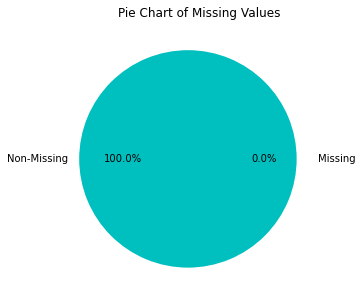

In [9]:
%%time

# plot proportion NaN
try:
    str_filename = 'plt_prop_nan.png',
    func.plot_proportion_nan(
        df=df,
        str_dirname_output=f'{str_dirname_output}/{str_variant}',
        str_filename=str_filename,
    )
except:
    pass

### Plot data type frequency

100%|███████████████████████████████████████████████████████████████████████████| 2021/2021 [00:00<00:00, 24344.66it/s]


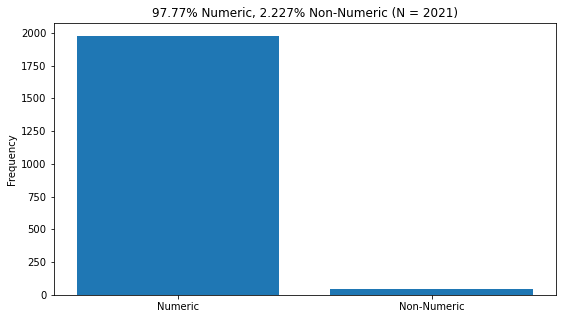

Wall time: 389 ms


In [10]:
%%time

# plot data type frequency
str_filename = 'plt_dtype.png'
func.plot_data_type_frequency(
    df=df,
    str_dirname_output=f'{str_dirname_output}/{str_variant}',
    str_filename=str_filename,
)